In [49]:
import pandas as pd
import matplotlib.pyplot as plt
# Load the dataset
# https://www.hpcf.upr.edu/~abel/phl/hwc/data/hwc.csv
df = pd.read_csv(r'C:\Users\ryanh\OneDrive\Documents\GitHub\Exo-planet-Analysis\Notebooks\Datasets\Habitable_worlds_full_dataset_ADJUSTED.csv')
pd.set_option('display.max_colwidth', None) #Remove limitation of column width
pd.set_option('display.max_columns', None) #Remove limitation of columns displayed
pd.set_option('display.max_rows', None) #Remove limitation of rows displayed

Following the intial data analysis and generation of a data catalogue from research and inference, a smaller subset of the dataset was made with only columns that were understood and deemed useful. This has reduced the dataset down to 32 columns for consideration. with 12 being specific to the planet, 16 being specific to the host star and 4 being classifiers that were generated by the origianl data hosts.

In [50]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5599 entries, 0 to 5598
Data columns (total 32 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   P_NAME         5599 non-null   object 
 1   P_MASS         5592 non-null   float64
 2   P_RADIUS       5592 non-null   float64
 3   P_PERIOD       5350 non-null   float64
 4   P_GRAVITY      5592 non-null   float64
 5   P_DENSITY      5592 non-null   float64
 6   P_DISTANCE     5595 non-null   float64
 7   P_FLUX         5365 non-null   float64
 8   P_TEMP_EQUIL   5365 non-null   float64
 9   P_TEMP_SURF    2441 non-null   float64
 10  P_TYPE         5592 non-null   object 
 11  P_TYPE_TEMP    5365 non-null   object 
 12  S_NAME         5599 non-null   object 
 13  S_TYPE_TEMP    5405 non-null   object 
 14  S_RA           5599 non-null   float64
 15  S_DEC          5599 non-null   float64
 16  S_MAG          5380 non-null   float64
 17  S_TEMPERATURE  5380 non-null   float64
 18  S_MASS  

From this output there are clearly at least 1 column that will not be used in the final analysis piece, namely the planets surface temperature (P_TEMP_SURF). There are also some columns that will require some adjustments to make a complete datafield which we can use in our analysis.

In [51]:
df2 = df.dropna(subset=['S_TYPE_TEMP'], inplace=False) # Drop rows where 'S_TYPE_TEMP' is NaN
print(df2.isnull().sum()) #Check for missing values. For the planetary parameters, the maximum number of missing values is 68 which is 1.26% of the column. This is low enough that we will fill the missing values with the median of each column. This is a common practice to handle missing data, especially when the data is not normally distributed.

df2.fillna({'P_GRAVITY': df2['P_GRAVITY'].median(),
            'P_PERIOD': df2['P_PERIOD'].median(),
            'P_RADIUS': df2['P_RADIUS'].median(),
            'P_MASS': df2['P_MASS'].median(),
            'P_DENSITY': df2['P_DENSITY'].median(),
            'P_DISTANCE': df2['P_DISTANCE'].median(), 
            'P_FLUX': df2['P_FLUX'].median(),
            'P_TEMP_EQUIL': df2['P_TEMP_EQUIL'].median()
            }, inplace=True) # Fill remaining NaN values for the planetary parameters with the median of each column


P_NAME              0
P_MASS              7
P_RADIUS            7
P_PERIOD           68
P_GRAVITY           7
P_DENSITY           7
P_DISTANCE          1
P_FLUX             41
P_TEMP_EQUIL       41
P_TEMP_SURF      2964
P_TYPE              7
P_TYPE_TEMP        41
S_NAME              0
S_TYPE_TEMP         0
S_RA                0
S_DEC               0
S_MAG              33
S_TEMPERATURE      27
S_MASS              4
S_RADIUS           41
S_METALLICITY     239
S_LUMINOSITY       40
S_HZ_OPT_MIN       40
S_HZ_OPT_MAX       40
S_HZ_CON_MIN       40
S_HZ_CON_MAX       40
S_SNOW_LINE        40
S_ABIO_ZONE        31
P_HABZONE_OPT       0
P_HABZONE_CON       0
P_HABITABLE         0
P_ESI              48
dtype: int64


C:\Users\ryanh\AppData\Local\Temp\ipykernel_35744\820423694.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2.fillna({'P_GRAVITY': df2['P_GRAVITY'].median(),


Looking at the data available I have decide that for this project I will focus on using a k-means clustering algorithm to identify clusters of similar planets to see if there is any commonality between the groups formed and the statistics for the corresponding star. 

What I hope to find is that planets in the same cluster, orbit the same classification of star, providing an algorithmic system of identifying a star's temperature type from the information about a given planet.

Through my research I have discovered that white dwarf stars, pulsars and binary star systems (denoted WD, PSR & BD in the S_TYPE_TEMP field) act very different to the other star systems and thus are skewing the data. For this reason they will be removed from consideration.

In [54]:
analysis_df = df2[~df2['S_TYPE_TEMP'].isin(['PSR','WD','BD'])] # Filter the dataset to only include habitable planets
print(analysis_df.info()) # Check the info of the filtered dataset

<class 'pandas.core.frame.DataFrame'>
Index: 5393 entries, 1 to 5597
Data columns (total 32 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   P_NAME         5393 non-null   object 
 1   P_MASS         5393 non-null   float64
 2   P_RADIUS       5393 non-null   float64
 3   P_PERIOD       5393 non-null   float64
 4   P_GRAVITY      5393 non-null   float64
 5   P_DENSITY      5393 non-null   float64
 6   P_DISTANCE     5393 non-null   float64
 7   P_FLUX         5393 non-null   float64
 8   P_TEMP_EQUIL   5393 non-null   float64
 9   P_TEMP_SURF    2441 non-null   float64
 10  P_TYPE         5386 non-null   object 
 11  P_TYPE_TEMP    5363 non-null   object 
 12  S_NAME         5393 non-null   object 
 13  S_TYPE_TEMP    5393 non-null   object 
 14  S_RA           5393 non-null   float64
 15  S_DEC          5393 non-null   float64
 16  S_MAG          5368 non-null   float64
 17  S_TEMPERATURE  5373 non-null   float64
 18  S_MASS       

C:\Users\ryanh\AppData\Local\Temp\ipykernel_35744\2280197161.py:2: UserWarning: When passing multiple axes, sharex and sharey are ignored. These settings must be specified when creating axes.
  boxplot = analysis_df.boxplot(column=['P_MASS', 'P_GRAVITY', 'P_RADIUS', 'P_PERIOD', 'P_DENSITY', 'P_DISTANCE', 'P_FLUX', 'P_TEMP_EQUIL'], by = 'S_TYPE_TEMP', ax=axs, showfliers=True) # Create boxplots for each planetary parameter grouped by stellar type


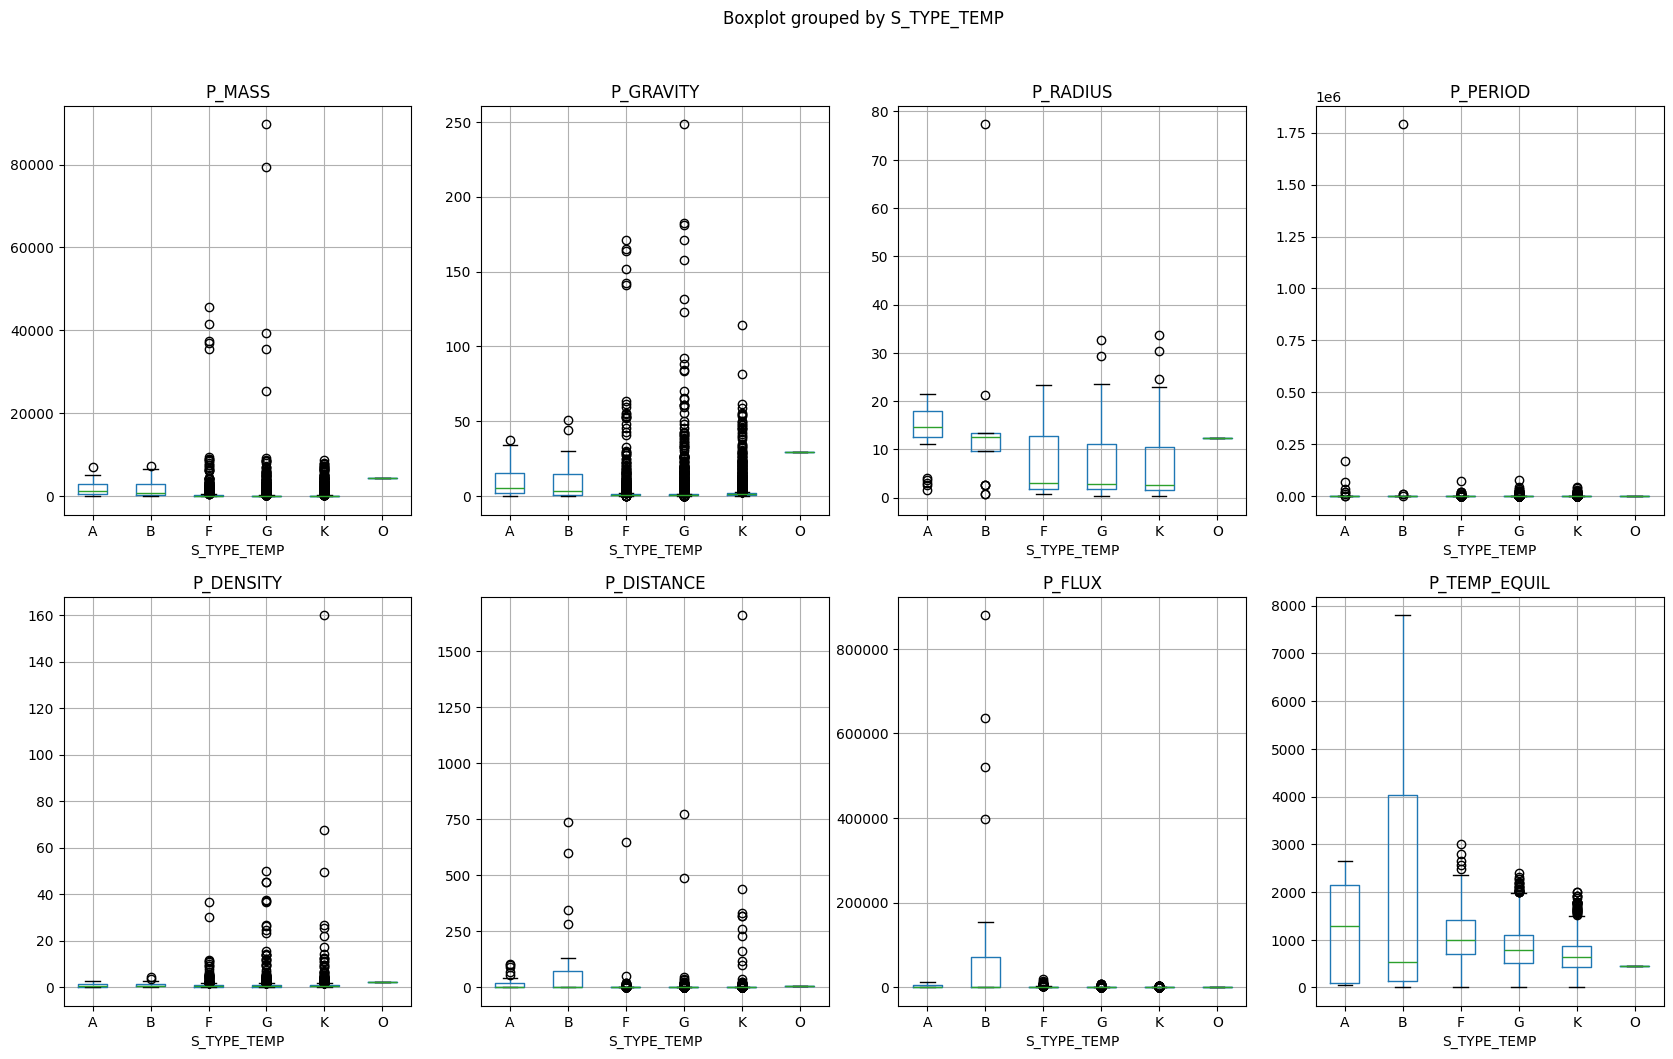

In [53]:
fig, axs = plt.subplots(2, 4, figsize=(20, 12), sharey=False) # Create subplots for each group of habitable planets
boxplot = analysis_df.boxplot(column=['P_MASS', 'P_GRAVITY', 'P_RADIUS', 'P_PERIOD', 'P_DENSITY', 'P_DISTANCE', 'P_FLUX', 'P_TEMP_EQUIL'], by = 'S_TYPE_TEMP', ax=axs, showfliers=True) # Create boxplots for each planetary parameter grouped by stellar type

Boxplots show distinct variance between the start types across each field, with some showing more promise than others. For example, equilibrium temperature shows a clear difference between each of the star groups, where as period length shows very little visual differences names due to the massive size of some outliers.

However, it is notable that when outliers are removed alot more of the data fields show a clear seperation between star types. Most notably density shows very clear distinctions between the star classifications.

C:\Users\ryanh\AppData\Local\Temp\ipykernel_35744\237839996.py:2: UserWarning: When passing multiple axes, sharex and sharey are ignored. These settings must be specified when creating axes.
  boxplot2 = analysis_df.boxplot(column=['P_MASS', 'P_GRAVITY', 'P_RADIUS', 'P_PERIOD', 'P_DENSITY', 'P_DISTANCE', 'P_FLUX', 'P_TEMP_EQUIL'], by = 'S_TYPE_TEMP', ax=axs, showfliers=False) # Create boxplots for each planetary parameter grouped by stellar type without outliers


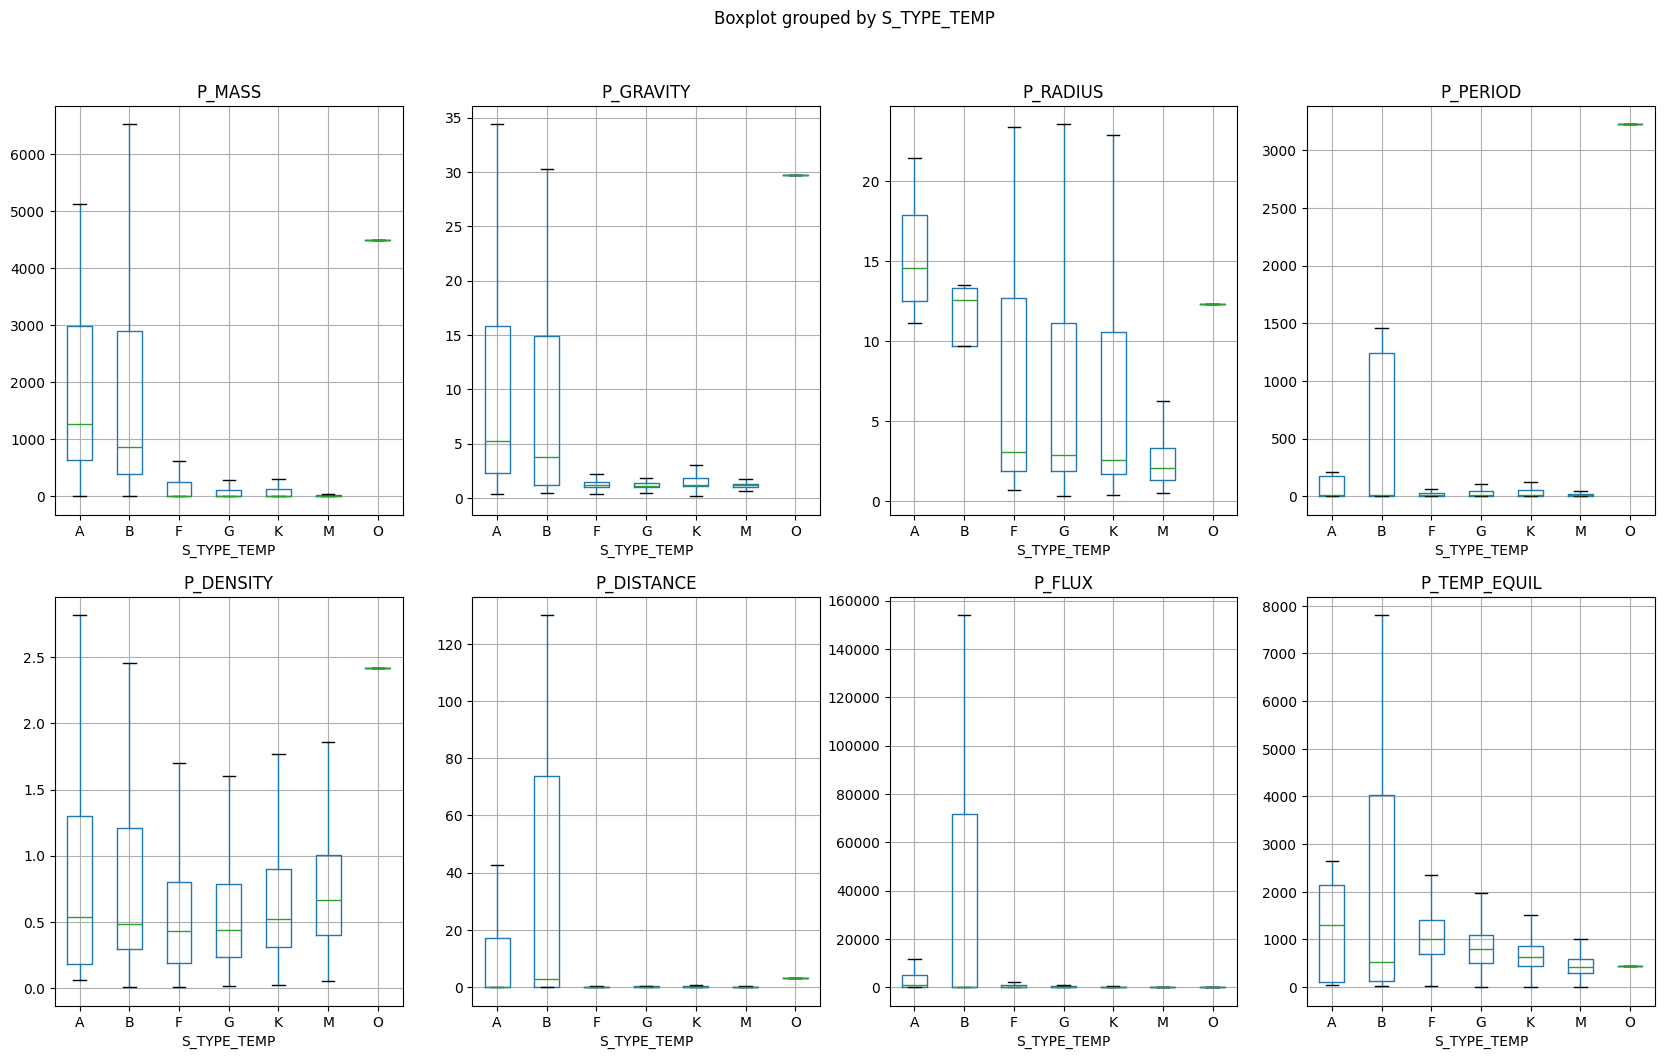

In [59]:
fig, axs = plt.subplots(2, 4, figsize=(20, 12), sharey=False) # Create subplots for each group of habitable planets
boxplot2 = analysis_df.boxplot(column=['P_MASS', 'P_GRAVITY', 'P_RADIUS', 'P_PERIOD', 'P_DENSITY', 'P_DISTANCE', 'P_FLUX', 'P_TEMP_EQUIL'], by = 'S_TYPE_TEMP', ax=axs, showfliers=False) # Create boxplots for each planetary parameter grouped by stellar type without outliers

With the above visuals it is clear that there are some fields that are better than others for showing a seperation between classes but there is no one or two clear 'winners' that show the most seperation. For this reason I am going to use principle component analysis to generate two principle components which represent most of the variation and use these two as my fields for clustering.